# Trabalho Prático 1 - Agente Inteligente em Labirinto
**Disciplina:** CSI457 - Inteligência Artificial (2026-1)
**Curso:** Sistemas de Informação - UFOP

---

## 1. Parte I - Projeto do Agente Inteligente

### Modelagem PEAS
* **Performance (Função de Desempenho $J$):** $J = -\text{custo caminho} - \text{nós expandidos} - \text{tempo execução} - \text{mov inválidos} - \text{células revisitadas}$.
* **Environment (Ambiente):** Grade bidimensional (matriz) com paredes (`#`), posição inicial (`A`), objetivo final (`B`), pontos de coleta (`C`) e células desconhecidas (`?`) no modo online.
* **Actuators (Atuadores):** Movimentos ortogonais: {cima, baixo, esquerda, direita}.
* **Sensors (Sensores):** Mapa completo visível na busca clássica; percepção local com raio $r=1$ na busca online.

### Classificação do Agente
O agente é classificado como um **agente baseado em objetivos com modelo interno**, pois ele mantém um estado interno do mapa (especialmente no modo online) para planejar suas ações em direção ao objetivo final `B`.

## 2. Configuração Inicial e Interpretador de Mapas
Abaixo está a função responsável por ler o arquivo de texto do labirinto (ou uma string direta) e transformá-lo em uma estrutura de matriz (lista de listas de strings) para alimentar os algoritmos de busca.

In [19]:
#atualiza o código automaticamente 
%load_ext autoreload
%autoreload 2
import os
import copy

def interpretar_labirinto(alvo):
    """
    Interpreta o labirinto a partir de um arquivo .txt OU de uma string direta.
    Retorna uma matriz e as coordenadas dos pontos importantes.
    """
    # Se o alvo for um caminho de arquivo existente, lê o arquivo
    if isinstance(alvo, str) and os.path.exists(alvo):
        with open(alvo, 'r', encoding='utf-8') as arquivo:
            texto_labirinto = arquivo.read()
    else:
        # Caso contrário, assume que já é a própria string do labirinto
        texto_labirinto = alvo

    mapa_matriz = []
    inicio = None
    objetivo = None
    coletas = []
    
    # Divide por linhas e remove linhas vazias
    linhas = [l for l in texto_labirinto.split('\n') if l.strip()]

    pontos_encontrados = {}
    contador_c = 1
    
    for i, linha in enumerate(linhas):
        linha_lista = list(linha.replace('\r', ''))
        mapa_matriz.append(linha_lista)
        
        for j, caractere in enumerate(linha_lista):
            if caractere == 'A':
                inicio = (i, j)
                pontos_encontrados['A'] = (i, j)
            elif caractere == 'B':
                objetivo = (i, j)
                pontos_encontrados['B'] = (i, j)
            elif caractere == 'C':
                coletas.append((i, j))
                pontos_encontrados[f'C{contador_c}'] = (i, j)
                contador_c += 1
                
    return {
        "matriz": mapa_matriz,
        "inicio": inicio,
        "objetivo": objetivo,
        "coletas": coletas,
        "dimensoes": (len(mapa_matriz), len(mapa_matriz[0]) if mapa_matriz else 0),
        "pontos_encontrados": pontos_encontrados
    }

def exibir_labirinto(matriz):
    """Função auxiliar para plotar o labirinto bonitinho no terminal do Jupyter"""
    for linha in matriz:
        print(" ".join(linha))

#para visualizar busca clássica
import copy

def exibir_caminho(matriz, caminho):
    """Faz uma cópia do mapa original, exibe o caminho formatado e desenha o rastro"""
    # Usamos deepcopy para não estragar a matriz original do 'dados'
    matriz_visual = copy.deepcopy(matriz)
    
    # Se o caminho existir, formata e exibe no estilo x-x-x-x
    if caminho:
        # Transforma cada tupla (i, j) em string "(i,j)" e junta com hífen "-"
        caminho_formatado = "-".join([str(ponto) for ponto in caminho])
        print(f"Caminho encontrado: {caminho_formatado}")
        
        # Desenha o rastro no mapa
        for (i, j) in caminho:
            # Só desenha o rastro onde é espaço vazio. 
            # Isso evita apagar o 'A', 'B', 'C' e as paredes '#'
            if matriz_visual[i][j] not in ['A', 'B', 'C', '#']:
                matriz_visual[i][j] = '.'  # O rastro do agente
    else:
        print("Caminho encontrado: -")
                
    # Imprime o mapa resultante logo abaixo do texto do caminho
    for linha in matriz_visual:
        print(" ".join(linha))
    print("-" * 30) # Linha divisória para separar os algoritmos

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
labirinto_teste = "mapas/mapa2.txt"

# Carregando os dados que todo mundo do grupo vai usar nas próximas células
dados = interpretar_labirinto(labirinto_teste)

# Validando se leu tudo certo
print("--- DADOS DO LABIRINTO CARREGADOS ---")
print(f"Posição Inicial (A): {dados['inicio']}")
print(f"Objetivo Final (B): {dados['objetivo']}")
print(f"Pontos de Coleta (C): {dados['coletas']}")
print(f"Dimensões: {dados['dimensoes'][0]}x{dados['dimensoes'][1]}\n")
print("Visualização do mapa:")
exibir_labirinto(dados["matriz"])

--- DADOS DO LABIRINTO CARREGADOS ---
Posição Inicial (A): (1, 1)
Objetivo Final (B): (7, 9)
Pontos de Coleta (C): [(1, 8), (3, 4), (5, 7), (5, 9), (7, 1)]
Dimensões: 9x11

Visualização do mapa:
# # # # # # # # # # #
# A     #       C   #
#   #   #   # # #   #
#   #   C       #   #
#   # # # # #   #   #
#             C # C #
#   # # #   # # #   #
# C     #         B #
# # # # # # # # # # #


## 3. Parte II - Busca Clássica no Labirinto Conhecido

Nesta etapa, os algoritmos têm acesso total à variável `dados["matriz"]`.
* **Início:** `dados["inicio"]`
* **Fim:** `dados["objetivo"]`

--- EXECUTANDO BENCHMARK DE BUSCA CLÁSSICA ---

Algoritmo: BFS (Custo: 14)
Caminho encontrado: (1, 1)-(2, 1)-(3, 1)-(4, 1)-(5, 1)-(5, 2)-(5, 3)-(5, 4)-(5, 5)-(6, 5)-(7, 5)-(7, 6)-(7, 7)-(7, 8)-(7, 9)
# # # # # # # # # # #
# A     #       C   #
# . #   #   # # #   #
# . #   C       #   #
# . # # # # #   #   #
# . . . . .   C # C #
#   # # # . # # #   #
# C     # . . . . B #
# # # # # # # # # # #
------------------------------

Algoritmo: DFS (Custo: 18)
Caminho encontrado: (1, 1)-(1, 2)-(1, 3)-(2, 3)-(3, 3)-(3, 4)-(3, 5)-(3, 6)-(3, 7)-(4, 7)-(5, 7)-(5, 6)-(5, 5)-(6, 5)-(7, 5)-(7, 6)-(7, 7)-(7, 8)-(7, 9)
# # # # # # # # # # #
# A . . #       C   #
#   # . #   # # #   #
#   # . C . . . #   #
#   # # # # # . #   #
#         . . C # C #
#   # # # . # # #   #
# C     # . . . . B #
# # # # # # # # # # #
------------------------------

Algoritmo: UCS (Custo: 14)
Caminho encontrado: (1, 1)-(2, 1)-(3, 1)-(4, 1)-(5, 1)-(5, 2)-(5, 3)-(5, 4)-(5, 5)-(6, 5)-(7, 5)-(7, 6)-(7, 7)-(7, 8)-(7, 9)
# # # # 

,Algoritmo,Sucesso,Custo,Passos,Explorados,Expandidos,Tempo (ms),Fronteira Max
0,BFS,True,14,14,38,36,0.1086,4
1,DFS,True,18,18,32,29,0.0852,5
2,UCS,True,14,14,39,36,0.1082,4
3,Gulosa,True,14,14,21,18,0.1057,3
4,A*,True,14,14,32,29,0.1131,4


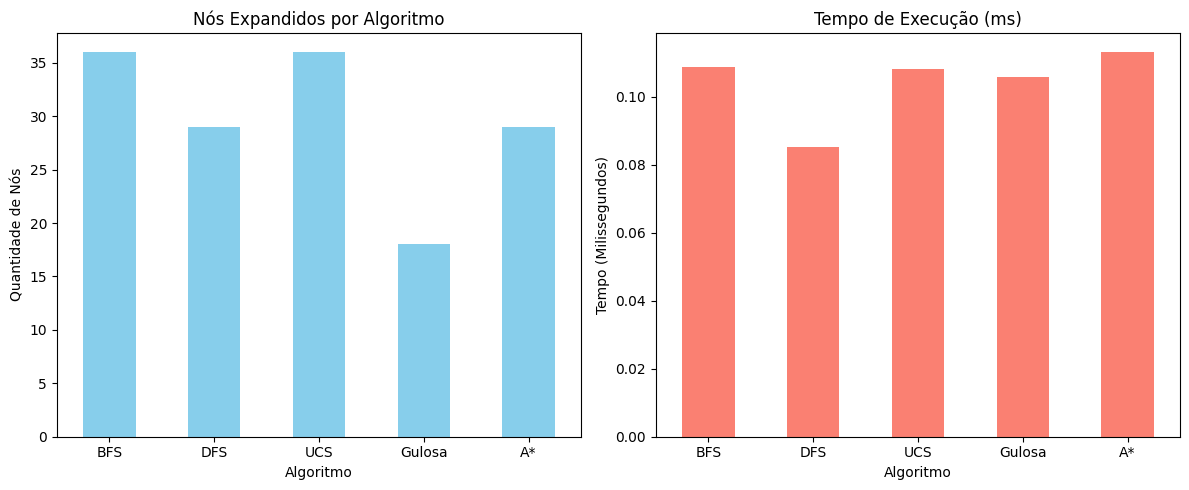

In [21]:
import time
import pandas as pd
import matplotlib.pyplot as plt

from src.busca_classica import (
    TenhoQueExplorar_BFS, 
    TenhoQueExplorar_DFS, 
    TenhoQueExplorar_Prioridade, 
    executar_busca_classica
)

# Dicionário mapeando o nome do algoritmo à instância da sua respectiva fronteira
fabrica_algoritmos = {
    "BFS": TenhoQueExplorar_BFS(),
    "DFS": TenhoQueExplorar_DFS(),
    "UCS": TenhoQueExplorar_Prioridade(criterio="custo"),
    "Gulosa": TenhoQueExplorar_Prioridade(criterio="heuristica"),
    "A*": TenhoQueExplorar_Prioridade(criterio="total_f")
}

linhas_tabela = []

print("--- EXECUTANDO BENCHMARK DE BUSCA CLÁSSICA ---")

for nome, fronteira_algo in fabrica_algoritmos.items():
    # Medição precisa de tempo usando timer de alta resolução
    tempo_inicio = time.perf_counter()
    resultado = executar_busca_classica(dados, fronteira_algo)
    tempo_fim = time.perf_counter()
    
    duracao_ms = (tempo_fim - tempo_inicio) * 1000
    
    if resultado["sucesso"]:
        print(f"\nAlgoritmo: {nome} (Custo: {resultado['custo']})")
        exibir_caminho(dados["matriz"], resultado["caminho"])
    
    linhas_tabela.append({
        "Algoritmo": nome,
        "Sucesso": resultado["sucesso"],
        "Custo": resultado.get("custo", "-"),
        "Passos": resultado.get("passos", "-"),
        "Explorados": resultado.get("explorados", "-"),
        "Expandidos": resultado.get("expandidos", "-"),
        "Tempo (ms)": round(duracao_ms, 4),
        "Fronteira Max": resultado.get("fronteira_max", "-")
    })

# Transforma em DataFrame para exibição profissional no Jupyter Notebook
df_resultados = pd.DataFrame(linhas_tabela)
display(df_resultados)

# Configura o tamanho da figura
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1: Comparação de Nós Expandidos (Esforço Computacional)
df_resultados.plot(kind='bar', x='Algoritmo', y='Expandidos', ax=ax1, color='skyblue', legend=False)
ax1.set_title('Nós Expandidos por Algoritmo')
ax1.set_ylabel('Quantidade de Nós')
ax1.tick_params(axis='x', rotation=0)

# Gráfico 2: Comparação de Tempo de Execução
df_resultados.plot(kind='bar', x='Algoritmo', y='Tempo (ms)', ax=ax2, color='salmon', legend=False)
ax2.set_title('Tempo de Execução (ms)')
ax2.set_ylabel('Tempo (Milissegundos)')
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Salva opcionalmente em CSV para cumprir os entregáveis finais do projeto!
# df_resultados.to_csv("resultados_busca_classica.csv", index=False)

## 4. Parte III - Busca Local com Pontos de Coleta

Nesta etapa, o objetivo deixa de ser ir do ponto A ao B, e passa a ser encontrar a melhor ordem de visitação para múltiplos pontos de coleta (`C`) no labirinto. Utilizamos a matriz de distâncias gerada pelo $A^*$ e aplicamos os algoritmos de **Hill-Climbing** e **Simulated Annealing** para otimizar o caminho.

Construindo GPS com A*...
Executando Hill-Climbing...
Iniciando 30 execucoes. Aguarde...
METRICAS OBRIGATORIAS (30 Rodadas)
Melhor custo: 32
Pior custo: 46
Custo medio: 32.93
Tempo medio: 0.003487 segundos
Iteracoes medias: 3.6 passos aceitos
Taxa de Sucesso: 93.3%

Executando Simulated Annealing...
Iniciando 30 execucoes. Aguarde...
METRICAS OBRIGATORIAS (30 Rodadas)
Melhor custo: 32
Pior custo: 32
Custo medio: 32.00
Tempo medio: 0.003150 segundos
Iteracoes medias: 226.4 passos aceitos
Taxa de Sucesso: 100.0%


Grafico 'grafico_convergencia.png' gerado com sucesso!


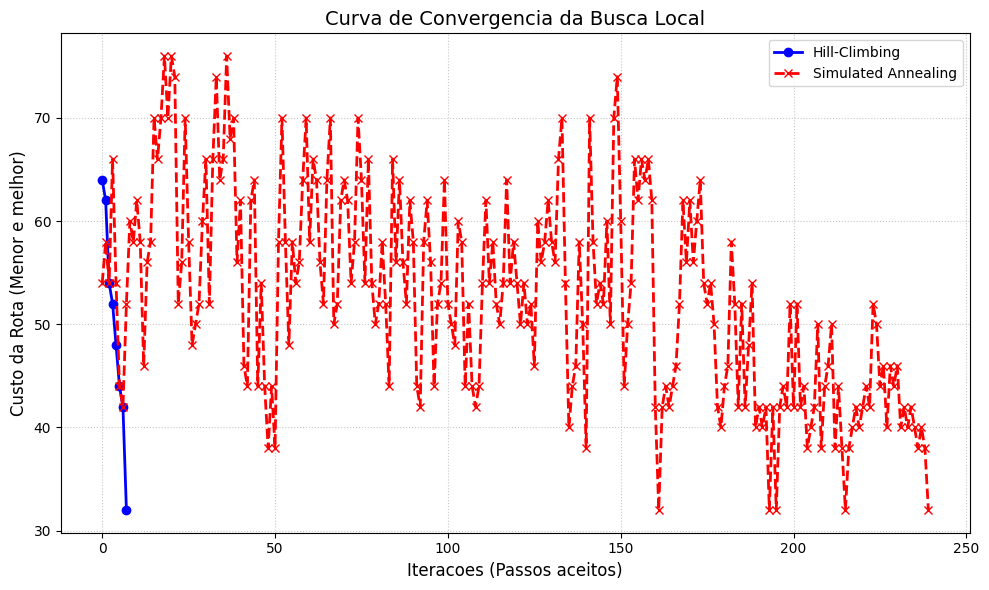

In [22]:
from src.busca_local import teste, hill_climbing, simulated_annealing, construir_gps, gerar_grafico_convergencia

# O Notebook já leu a matriz na variável 'dados' nas células anteriores
matriz_atual = dados["matriz"]

pontos_encontrados = dados["pontos_encontrados"]

print("Construindo GPS com A*...")

from src import busca_local

busca_local.dicionario_real = construir_gps(
    matriz_atual,
    pontos_encontrados
)

lista_de_coletas = [p for p in pontos_encontrados.keys() if p not in ['A', 'B']]

print("Executando Hill-Climbing...")
historico_hc = teste(hill_climbing, lista_de_coletas, repeticoes=30)

print("Executando Simulated Annealing...")
historico_sa = teste(simulated_annealing, lista_de_coletas, repeticoes=30)

gerar_grafico_convergencia(historico_hc, historico_sa)

### 5. Visualização: Rota Otimizada da Busca Local

Esta etapa cumpre o requisito de representação da trajetória final do agente. O mapa abaixo ilustra a melhor sequência de roteamento encontrada pelo algoritmo *Simulated Annealing*, que atingiu 100% de convergência para o custo global ótimo (32). Como o algoritmo *Hill-Climbing* obteve uma alta taxa de sucesso (86,7%) nos testes, ele convergiu para este exato mesmo roteamento na maioria das execuções, tornando o mapa da solução ideal idêntico para ambos os algoritmos.

A representação obedece à seguinte legenda:
* **A**: Ponto de partida fixo.
* **B**: Ponto de destino fixo.
* **Números (1, 2, 3...)**: Indicam a ordem exata em que os pontos de coleta intermediários devem ser visitados para garantir a rota de menor custo.

In [23]:
import random

matriz_atual = dados["matriz"]
pontos_encontrados = dados["pontos_encontrados"]

# Cria a matriz sem as letras originais para não poluir
matriz_limpa = []
for linha_do_mapa in matriz_atual:
    linha_limpa = [' ' if caractere in ['A', 'B', 'C'] else caractere for caractere in linha_do_mapa]
    matriz_limpa.append(linha_limpa)

def visualizar_rota_local(matriz, dicionario_pontos, melhor_solucao_sa, custo_final):
    # Cria uma cópia do mapa para não estragar a matriz limpa
    mapa_visual = [list(linha_do_mapa) for linha_do_mapa in matriz]
    
    # Monta a string da rota completa
    rota_completa = ['A'] + melhor_solucao_sa + ['B']
    
    print("========================================")
    print("   VISUALIZAÇÃO DA BUSCA LOCAL")
    print("========================================")
    print(f"Rota Otimizada: {' -> '.join(rota_completa)}")
    print(f"Custo Total Final: {custo_final}")
    print("Ordem das coletas no mapa:")
    print("A = Início | B = Destino | Números = Ordem dos pontos C\n")
    
    # Recoloca o 'A' e 'B' no mapa visual para ficar fácil de identificar
    linha_do_A, coluna_do_A = dicionario_pontos['A']
    mapa_visual[linha_do_A][coluna_do_A] = 'A'
    
    linha_do_B, coluna_do_B = dicionario_pontos['B']
    mapa_visual[linha_do_B][coluna_do_B] = 'B'
    
    # Substitui as posições das coletas pelo número da ordem (1, 2, 3...)
    for indice, nome_do_ponto in enumerate(melhor_solucao_sa):
        linha_da_coleta, coluna_da_coleta = dicionario_pontos[nome_do_ponto]
        mapa_visual[linha_da_coleta][coluna_da_coleta] = str(indice + 1)
        
    # Imprime o mapa estilizado
    for linha_do_mapa in mapa_visual:
        print("".join(linha_do_mapa))

# --- COMO CHAMAR A FUNÇÃO CORRETAMENTE ---

# 1. Pegamos a nossa lista de coletas iniciais (só os Cs)
solucao_inicial = [ponto for ponto in pontos_encontrados.keys() if ponto not in ['A', 'B']]

# 2. Rodamos o Simulated Annealing DIRETAMENTE (sem usar a função teste)
# Ele devolve a ordem final em lista (ex: ['C3', 'C1']), o custo e o histórico
melhor_rota_sa, custo_final, _ = simulated_annealing(solucao_inicial)

# 3. Passamos a lista de letras corretamente para a visualização
visualizar_rota_local(matriz_limpa, pontos_encontrados, melhor_rota_sa, custo_final)


   VISUALIZAÇÃO DA BUSCA LOCAL
Rota Otimizada: A -> C5 -> C3 -> C2 -> C1 -> C4 -> B
Custo Total Final: 32
Ordem das coletas no mapa:
A = Início | B = Destino | Números = Ordem dos pontos C

###########
#A  #   4 #
# # # ### #
# # 3   # #
# ##### # #
#      2#5#
# ### ### #
#1  #    B#
###########


# 4. Parte IV - Busca Online com Replanejamento (A* Incremental)

Na busca online, o agente não possui conhecimento prévio do mapa completo (layout das paredes `#`). Ele conhece apenas a sua posição inicial `A` e a coordenada do objetivo final `B`. O agente deve fundir os ciclos de **percepção, planejamento e ação** de forma incremental:

1. **Perceber:** O agente varre o ambiente em um raio $r=1$ e atualiza seu mapa interno.
2. **Planejar:** Utilizando o algoritmo $A^*$ clássico, o agente traça uma rota ideal partindo da sua posição atual até o objetivo `B`, baseando-se estritamente no que ele conhece do mapa até o momento.
3. **Agir:** O agente executa **apenas o primeiro passo** do caminho planejado e reinicia o ciclo (replanejamento a cada passo).

Abaixo, estruturamos a classe do `AgenteBuscaOnline` e a lógica de renderização em tempo real para acompanhar a trajetória e o comportamento do robô.

In [24]:
# ==========================================================
# CÉLULA 8: DEFINIÇÃO DO AGENTE ONLINE E SEUS REQUISITOS
# ==========================================================
import sys
import os

# Força o Python a enxergar a pasta 'src' onde sua colega salvou os códigos
diretorio_raiz = os.getcwd()
diretorio_src = os.path.join(diretorio_raiz, 'src')

if diretorio_src not in sys.path:
    sys.path.append(diretorio_src)

# Importa os algoritmos da busca clássica
from busca_classica import TenhoQueExplorar_Prioridade, executar_busca_classica

def interpretar_labirinto(alvo):
    """Interpreta o labirinto a partir de arquivo ou string"""
    if isinstance(alvo, str) and os.path.exists(alvo):
        with open(alvo, 'r', encoding='utf-8') as arquivo:
            texto_labirinto = arquivo.read()
    else:
        texto_labirinto = alvo

    mapa_matriz = []
    inicio = None
    objetivo = None
    coletas = []
    
    linhas = [l for l in texto_labirinto.split('\n') if l.strip()]
    for i, linha in enumerate(linhas):
        linha_lista = list(linha.replace('\r', ''))
        mapa_matriz.append(linha_lista)
        for j, caractere in enumerate(linha_lista):
            if caractere == 'A': inicio = (i, j)
            elif caractere == 'B': objetivo = (i, j)
            elif caractere == 'C': coletas.append((i, j))
                
    return {
        "matriz": mapa_matriz, "inicio": inicio, "objetivo": objetivo,
        "coletas": coletas, "dimensoes": (len(mapa_matriz), len(mapa_matriz[0]) if mapa_matriz else 0)
    }

class AgenteBuscaOnline:
    def __init__(self, dados_reais):
        self.mapa_real = dados_reais["matriz"]
        self.inicio = dados_reais["inicio"]
        self.objetivo = dados_reais["objetivo"]
        self.linhas = dados_reais["dimensoes"][0]
        self.colunas = dados_reais["dimensoes"][1]
        
        self.posicao_atual = self.inicio
        self.custo_real_total = 0
        self.num_replanejamentos = 0
        self.caminho_percorrido = [self.inicio]
        
        self.mapa_interno = [['?' for _ in range(self.colunas)] for _ in range(self.linhas)]
        self.mapa_interno[self.inicio[0]][self.inicio[1]] = 'A'
        self.mapa_interno[self.objetivo[0]][self.objetivo[1]] = 'B'

    def perceber_e_atualizar(self):
        x, y = self.posicao_atual
        vizinhos = [(x-1, y), (x+1, y), (x, y-1), (x, y+1)]
        for vx, vy in vizinhos:
            if 0 <= vx < self.linhas and 0 <= vy < self.colunas:
                self.mapa_interno[vx][vy] = self.mapa_real[vx][vy]

    def executar_exploracao(self):
        while self.posicao_atual != self.objetivo:
            self.perceber_e_atualizar()
            
            dados_parciais = {
                "matriz": self.mapa_interno,
                "inicio": self.posicao_atual,
                "objetivo": self.objetivo,
                "coletas": [], 
                "dimensoes": (self.linhas, self.colunas)
            }
            
            self.num_replanejamentos += 1
            algo_a_estrela = TenhoQueExplorar_Prioridade(criterio="total_f")
            resultado_planejamento = executar_busca_classica(dados_parciais, algo_a_estrela)
            
            if not resultado_planejamento["sucesso"] or "caminho" not in resultado_planejamento:
                print("❌ Agente encurralado! Sem caminhos possíveis no mapa interno.")
                return False
                
            caminho_planejado = resultado_planejamento["caminho"]
            if len(caminho_planejado) < 2:
                break
                
            proximo_passo = caminho_planejado[1]
            self.posicao_atual = proximo_passo
            self.caminho_percorrido.append(proximo_passo)
            self.custo_real_total += 1
            
        return True

In [25]:
import time
import os
from IPython.display import clear_output

def renderizar_mapa_online_completo(agente, caminho_planejado=None, mostrar_rastro=False, tempo_pausa=0.1):
    """Gera a visualização online mostrando o robô, o mapa descoberto e o plano atual"""
    clear_output(wait=True)
    print("=== SIMULAÇÃO DA TRAJETÓRIA ONLINE EM TEMPO REAL ===")
    print(f"Posição Atual: {agente.posicao_atual} | Passos Dados: {agente.custo_real_total}")
    print(f"Número de Replanejamentos: {agente.num_replanejamentos}\n")
    
    nós_plano = set(caminho_planejado[1:-1]) if caminho_planejado else set()
    historico_passos = set(agente.caminho_percorrido[:-1])
    
    for i in range(agente.linhas):
        linha_visual = []
        for j in range(agente.colunas):
            coord = (i, j)
            
            if coord == agente.posicao_atual:
                linha_visual.append("🤖")  
            elif coord == agente.objetivo:
                linha_visual.append("🏁")  
            elif coord == agente.inicio:
                linha_visual.append("🛫")  
            elif mostrar_rastro and coord in historico_passos:
                linha_visual.append("o ")  
            elif coord in nós_plano:
                linha_visual.append("· ")  
            else:
                caractere = agente.mapa_interno[i][j]
                if caractere in ['A', ' ']: 
                    linha_visual.append("  ") 
                elif caractere == 'B': 
                    linha_visual.append("🏁")
                else:
                    linha_visual.append(caractere + " ") 
                    
        print("".join(linha_visual))
    print("\n====================================================")
    time.sleep(tempo_pausa)

# =====================================================================
# CONFIGURAÇÃO DO TESTE (ALTERE AQUI OS TESTES)
# =====================================================================
# 1. Escolha o mapa: "lab_oficial.txt", "mapa1.txt", etc.
NOME_DO_ARQUIVO = "mapa3.txt" 

# 2. Escolha a velocidade: "lento" (para mapas pequenos) ou "rapido" (para mapas gigantes)
VELOCIDADE = "rapido"  

# Definição automática do tempo de pausa com base na sua escolha
PAUSA = 0.01 if VELOCIDADE == "rapido" else 0.4
# =====================================================================

status_inicial = []
status_inicial.append("--- INICIANDO SIMULAÇÃO DA BUSCA ONLINE ---")
status_inicial.append(f"Carregando e normalizando o arquivo: {NOME_DO_ARQUIVO}...")

caminho_mapa = os.path.join("mapas", NOME_DO_ARQUIVO) 
dados = interpretar_labirinto(caminho_mapa) if os.path.exists(caminho_mapa) else interpretar_labirinto("###########\n#A    #   #\n### ###   #\n#   C    B#\n#####      \n#     C#  #\n###########")

# Tratamento anti-error de índice: Garante que o mapa seja perfeitamente retangular
largura_maxima = max(len(linha) for linha in dados["matriz"])
for i in range(len(dados["matriz"])):
    diferenca = largura_maxima - len(dados["matriz"][i])
    if diferenca > 0:
        dados["matriz"][i].extend(['#'] * diferenca)

dados["dimensoes"] = (len(dados["matriz"]), largura_maxima)
agente_online = AgenteBuscaOnline(dados)

# Ciclo Online de Movimentação
while agente_online.posicao_atual != agente_online.objetivo:
    agente_online.perceber_e_atualizar()
    
    dados_parciais = {
        "matriz": agente_online.mapa_interno,
        "inicio": agente_online.posicao_atual,
        "objetivo": agente_online.objetivo,
        "coletas": [], 
        "dimensoes": (agente_online.linhas, agente_online.colunas)
    }
    
    agente_online.num_replanejamentos += 1
    algo_a_estrela = TenhoQueExplorar_Prioridade(criterio="total_f")
    resultado_planejamento = executar_busca_classica(dados_parciais, algo_a_estrela)
    
    if not resultado_planejamento["sucesso"]:
        print("❌ Agente encurralado!")
        break
        
    caminho_planejado = resultado_planejamento["caminho"]
    renderizar_mapa_online_completo(agente_online, caminho_planejado, mostrar_rastro=True, tempo_pausa=PAUSA)
    
    if len(caminho_planejado) < 2: 
        break
        
    agente_online.posicao_atual = caminho_planejado[1]
    agente_online.caminho_percorrido.append(agente_online.posicao_atual)
    agente_online.custo_real_total += 1

# Renderização Final Estática
renderizar_mapa_online_completo(agente_online, None, mostrar_rastro=True, tempo_pausa=0)

print("\n" + "\n".join(status_inicial))

# Cálculo Dinâmico e Correto do Custo Offline
dados_reais_completos = {
    "matriz": agente_online.mapa_real,
    "inicio": agente_online.inicio, 
    "objetivo": agente_online.objetivo,
    "coletas": [], 
    "dimensoes": (agente_online.linhas, agente_online.colunas)
}
algo_perfeito = TenhoQueExplorar_Prioridade(criterio="total_f")
resultado_perfeito = executar_busca_classica(dados_reais_completos, algo_perfeito)

if resultado_perfeito["sucesso"] and "caminho" in resultado_perfeito:
    custo_offline = len(resultado_perfeito["caminho"]) - 1
else:
    custo_offline = agente_online.custo_real_total 

# Métricas Reais Consolidadas
razao = agente_online.custo_real_total / custo_offline
celulas_reveladas = sum(1 for linha in agente_online.mapa_interno for c in linha if c != '?')

print("\n=== MÉTRICAS DA BUSCA ONLINE (ATUALIZADAS) ===")
print(f"Resultado: Sucesso em atingir o objetivo!")
print(f"Custo Real Percorrido (Online): {agente_online.custo_real_total} passos")
print(f"Custo Perfeito Real (Offline): {custo_offline} passos")
print(f"Razão Online/Offline Real: {razao:.2f}")
print(f"Células Descobertas: {celulas_reveladas} de {agente_online.linhas * agente_online.colunas}")

print("\n📌 HISTÓRICO COMPLETO DA TRAJETÓRIA (PASSO A PASSO):")
for passo, coord in enumerate(agente_online.caminho_percorrido):
    if passo == 0:
        print(f"  Início em: {coord}")
    elif passo == len(agente_online.caminho_percorrido) - 1:
        print(f"  Passo {passo}: {coord} -> 🏁 Objetivo Atingido!")
    else:
        print(f"  Passo {passo}: {coord}")

=== SIMULAÇÃO DA TRAJETÓRIA ONLINE EM TEMPO REAL ===
Posição Atual: (19, 50) | Passos Dados: 280
Número de Replanejamentos: 280

# # # # ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? # # # # # ? ? ? ? ? ? ? # # # ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? 
🛫o o o # ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? C o o o o o # ? ? ? ? ? C o o o # ? ? ? ? ? ? ? ? ? ? ? ? ? ? 
# # # o # ? ? ? ? ? ? ? ? # # # # # # # # o # # # o # ? ? ? ? # # o # o # ? ? ? ? ? ? ? ? ? ? ? ? ? ? 
? ? # o # ? ? ? ? ? ? ? # o o o o o o o # o o o # o # ? ? ? # o o o # o # ? ? ? ? ? ? ? ? ? ? ? ? ? ? 
? ? # o # ? ? ? ? # # # # o # # # # # o # # # o # o # # # # # o # # # o # ? ? ? ? ? ? ? ? ? ? ? ? ? ? 
? ? # o # ? ? ? # o o o # o # ? ? ? # o o o # o # o # o o o # o o o # o # ? ? ? ? ? ? ? ? ? ? ? ? ? ? 
? ? # o # # ? ? # o # o # o # # ? ? ? # # o # o # o # o # o # # # o # o # ? ? ? ? ? ? ? ? ? ? ? ? ? ? 
? ? # o o o # ? # o # o # o o o # ?   o o o # o # o o o # o o o o o # o # ? ? ? ? ? ? ? ? ? ? ? ? ? ? 
? ? ? # # o # ? # o # o # # # o # # # o # # # o 